# IT Support Dashboard - Supporting Notebook 4

This notebook continues from Notebook 3 by converting text recurrence signals into operationally interpretable clusters. It selects a robust `K`, labels clusters, and derives a prioritisation score for action planning.

## Clustering

This notebook applies `K-Means` to normalised `TF-IDF` vectors, evaluates candidate `K` values, and ranks resulting clusters by operational relevance.

Workflow summary:
- load sparse downstream `TF-IDF` features from Notebook 3 outputs
- evaluate configured `K` range with separation and over-segmentation checks
- select efficient screening initialisation via an adaptive `n_init` probe
- run targeted high-budget sensitivity checks
- choose final `K` using `Composite Score = Silhouette Score - Redundant Pair Ratio`
- generate cluster labels and derive `Actionability Score`

Value: this stage converts recurrence evidence into a reproducible prioritisation framework.

### Importing

Packages are imported, directories are validated, and downstream `TF-IDF` artefacts are loaded with sparse-first logic.

Value: this preserves feature fidelity while reducing memory overhead in clustering computations.

In [4]:
# Importing essential packages
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time
from scipy import sparse

# Add project root to sys.path by searching upward for config.py
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()), None
)
if project_root is None:
    raise FileNotFoundError("Could not locate project root containing config.py")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config  # noqa: E402

Config.ensure_directories()

# Prefer sparse TF-IDF export for downstream clustering efficiency.
tfidf_sparse = sparse.load_npz(Config.TFIDF_SPARSE_MATRIX_PATH).astype(np.float32)
feature_names = np.load(Config.TFIDF_FEATURE_NAMES_PATH, allow_pickle=True)

[Config] Verified project directory structure under C:\Users\cosmi\Documents\Projects\IT-Support-Ticket-Analysis


### Evaluating K Values

Candidate `K` values are screened using `Silhouette Score`, `Davies-Bouldin Score`, and median cluster-size thresholds.

Value: this stage narrows the search to viable candidates while controlling over-segmentation risk and runtime.

In [5]:
# Normalise TF-IDF once and keep it sparse for faster clustering
tfidf_normalised = normalize(tfidf_sparse, norm="l2", copy=False)
n_samples = tfidf_normalised.shape[0]  # use the actual sample being clustered

### N_init Probe

A representative `K` is used to select the minimum viable screening `n_init` before full-range evaluation.

Value: this reduces total screening cost while retaining reference-quality initialisation behaviour.

In [6]:
# n_init candidates in use across this notebook: [1, 5, 10, 20]
# Probe selects the minimum viable screening value from {1, 2, 3, 4, 5}

# Derive a representative probe K: the largest K satisfying all threshold
# minimum-cluster-size constraints simultaneously.
# Balanced-clustering bound: K <= floor(1 / most_restrictive_threshold).
probe_k = int(1.0 / max(Config.THRESHOLD_PERCENTS))

# Materialise the full dense matrix once for silhouette calculations.
tfidf_dense = tfidf_sparse.toarray()

print(f"Probing n_init candidates at K={probe_k} (up to ~6 mins)...")

# Reference score, where n_init=5
probe_labels_ref = KMeans(
    n_clusters=probe_k,
    random_state=Config.RANDOM_STATE,
    n_init=Config.KMEANS_SCREENING_N_INIT,
).fit_predict(tfidf_normalised)
sil_ref = silhouette_score(tfidf_dense, probe_labels_ref)
del probe_labels_ref

probe_log = [f"n_init={Config.KMEANS_SCREENING_N_INIT} (ref) -> sil={sil_ref:.6f}"]

# Escalate from n_init=1 upward, stopping as soon as a candidate matches or beats the reference.
# Best case: 2 KMeans fits total. Worst case: 5 (all candidates exhausted).
screening_n_init = Config.KMEANS_SCREENING_N_INIT
for candidate_n_init in [1, 2, 3, 4]:
    probe_labels = KMeans(
        n_clusters=probe_k,
        random_state=Config.RANDOM_STATE,
        n_init=candidate_n_init,
    ).fit_predict(tfidf_normalised)
    sil = silhouette_score(tfidf_dense, probe_labels)
    del probe_labels

    probe_log.append(f"n_init={candidate_n_init} -> sil={sil:.6f}")
    if sil >= sil_ref:
        screening_n_init = candidate_n_init
        break

print(f"n_init probe at K={probe_k}:")
for entry in probe_log:
    print(f"  {entry}")
print(f"Selected screening n_init: {screening_n_init}")

Probing n_init candidates at K=50 (up to ~6 mins)...
n_init probe at K=50:
  n_init=5 (ref) -> sil=0.025880
  n_init=1 -> sil=0.024627
  n_init=2 -> sil=0.024627
  n_init=3 -> sil=0.025880
Selected screening n_init: 3


### K-Means Screening

Candidate `K` values are evaluated with the selected `n_init`. This shows the number of different centroid initialisations K-Means tries before selecting its best solution.

In [7]:
# Define K search range from config; screening_n_init was selected by the probe above.
k_values = Config.K_SEARCH_RANGE

print(
    f"Evaluating KMeans clustering metrics across K values ({min(k_values)}-{max(k_values)}) "
    f"with screening n_init={screening_n_init} (60-90mins)..."
)

# Cache labels for every K in the screening range (used for diagnostics/reuse)
kmeans_labels_cache = {}

# Compute clustering metrics once per K
records = []
print(
    f"Evaluating KMeans for K={min(k_values)}-{max(k_values)} "
    f"(cut-offs based on n={n_samples:,})..."
)

# Identify K values that yield median cluster sizes around the defined thresholds
for k in k_values:
    # Record runtime because this is the most expensive step
    start_time = time.time()
    kmeans_model = KMeans(
        n_clusters=k, random_state=Config.RANDOM_STATE, n_init=screening_n_init
    )
    cluster_labels = kmeans_model.fit_predict(tfidf_normalised)
    kmeans_labels_cache[k] = cluster_labels

    # Compute silhouette and Davies-Bouldin scores on the full dataset.
    unique_labels = np.unique(cluster_labels)
    if unique_labels.size > 1:
        silhouette_avg = silhouette_score(tfidf_dense, cluster_labels)
        davies_bouldin_avg = davies_bouldin_score(tfidf_dense, cluster_labels)
    else:
        silhouette_avg = np.nan
        davies_bouldin_avg = np.nan

    cluster_sizes = np.bincount(cluster_labels)
    median_cluster_size = float(np.median(cluster_sizes))
    runtime_seconds = time.time() - start_time

    # Record results for this K
    records.append(
        {
            "K Value": k,
            "Silhouette Score": silhouette_avg,
            "Davies-Bouldin Score": davies_bouldin_avg,
            "Median Cluster Size": median_cluster_size,
            "Runtime (sec)": runtime_seconds,
            "n_init (Screening)": screening_n_init,
        }
    )

    # Print progress for this K
    print(
        f"K={k:<2d} | silhouette={silhouette_avg:.5f} | DB={davies_bouldin_avg:.3f} | "
        f"median={median_cluster_size:.0f} | runtime={runtime_seconds:.1f}s"
    )

# Release memory for the dense matrix, which is no longer needed after silhouette calculations.
del tfidf_dense

# Compile results into a DataFrame and sort by K Value
metrics_df = pd.DataFrame(records).sort_values("K Value").reset_index(drop=True)
metrics_df["Silhouette Score (x10e-2)"] = metrics_df["Silhouette Score"] * 100

# Save metrics to CSV for sharing and to parquet to skip this cell in future runs
metrics_df.to_csv(Config.KMEANS_CSV_PATH, index=False, encoding="utf-8")
metrics_df.to_parquet(
    Config.KMEANS_PARQUET_PATH, engine="pyarrow", compression="snappy"
)

display(
    metrics_df.style.format(
        {
            "Silhouette Score": "{:.3f}",
            "Davies-Bouldin Score": "{:.3f}",
            "Median Cluster Size": "{:.0f}",
            "Runtime (sec)": "{:.1f}",
            "n_init (Screening)": "{:.0f}",
        }
    )
)

Evaluating KMeans clustering metrics across K values (20-80) with screening n_init=3 (60-90mins)...
Evaluating KMeans for K=20-80 (cut-offs based on n=13,729)...
K=20 | silhouette=0.02305 | DB=5.806 | median=624 | runtime=11.8s
K=21 | silhouette=0.02441 | DB=5.719 | median=590 | runtime=11.9s
K=22 | silhouette=0.02442 | DB=5.548 | median=536 | runtime=12.0s
K=23 | silhouette=0.02445 | DB=5.600 | median=513 | runtime=11.7s
K=24 | silhouette=0.02540 | DB=5.658 | median=536 | runtime=11.8s
K=25 | silhouette=0.02474 | DB=5.657 | median=496 | runtime=11.8s
K=26 | silhouette=0.02411 | DB=5.616 | median=507 | runtime=12.0s
K=27 | silhouette=0.02500 | DB=5.585 | median=477 | runtime=12.1s
K=28 | silhouette=0.02469 | DB=5.592 | median=477 | runtime=12.1s
K=29 | silhouette=0.02412 | DB=5.640 | median=423 | runtime=11.8s
K=30 | silhouette=0.02150 | DB=5.633 | median=446 | runtime=11.9s
K=31 | silhouette=0.02388 | DB=5.282 | median=380 | runtime=11.8s
K=32 | silhouette=0.02383 | DB=5.505 | median=

,K Value,Silhouette Score,Davies-Bouldin Score,Median Cluster Size,Runtime (sec),n_init (Screening),Silhouette Score (x10e-2)
0,20,0.023,5.806,624,11.8,3,2.305110
1,21,0.024,5.719,590,11.9,3,2.440620
2,22,0.024,5.548,536,12.0,3,2.441673
3,23,0.024,5.600,513,11.7,3,2.445473
4,24,0.025,5.658,536,11.8,3,2.540203
5,25,0.025,5.657,496,11.8,3,2.473663
6,26,0.024,5.616,507,12.0,3,2.411166
7,27,0.025,5.585,477,12.1,3,2.499801
8,28,0.025,5.592,477,12.1,3,2.468999
9,29,0.024,5.640,423,11.8,3,2.412046


### Finding The Optimal K

Shortlisted candidates are evaluated through threshold constraints to identify three K values at the top thresholds.

In [8]:
# Importing KMeans results from parquet (can skip clustering cell if already done)
metrics_df = pd.read_parquet(Config.KMEANS_PARQUET_PATH, engine="auto")
metrics_df["Silhouette Score (x10e-2)"] = metrics_df["Silhouette Score"] * 100

# Prerequisite: tfidf_normalised must already exist from the previous preprocessing cell
n_samples = tfidf_normalised.shape[0]

# Thresholds are % of this sample size for the median cluster size
threshold_percents = Config.THRESHOLD_PERCENTS
threshold_abs = {t: n_samples * t for t in threshold_percents}

# For each threshold, pick the best k that is NOT over-segmented
optimal_rows = []
for threshold_perc in threshold_percents:
    cutoff = threshold_abs[threshold_perc]
    eligible_df = metrics_df[metrics_df["Median Cluster Size"] >= cutoff]

    if eligible_df.empty:
        chosen_row = metrics_df.loc[metrics_df["Silhouette Score"].idxmax()].copy()
        chosen_row["Note"] = "fallback_all_oversegmented"
        chosen_row["Oversegmentation"] = "True"
    else:
        chosen_row = (
            eligible_df.sort_values(
                ["Silhouette Score", "Davies-Bouldin Score"],
                ascending=[False, True],
            )
            .iloc[0]
            .copy()
        )
        chosen_row["Oversegmentation"] = "False"

    chosen_row["Threshold Proportion"] = threshold_perc
    chosen_row["Threshold Percent"] = f"{threshold_perc * 100:g}%"
    chosen_row["Threshold Abs"] = cutoff
    optimal_rows.append(chosen_row)

optimal_df = (
    pd.DataFrame(optimal_rows)
    .rename(columns={"K Value": "Optimal K"})
    .drop(columns=["Runtime (sec)"])
)

optimal_df = optimal_df[
    [
        "Threshold Proportion",
        "Threshold Percent",
        "Threshold Abs",
        "Optimal K",
        "Silhouette Score",
        "Silhouette Score (x10e-2)",
        "Davies-Bouldin Score",
        "Median Cluster Size",
        "Oversegmentation",
    ]
]

optimal_df.to_csv(Config.OPTIMAL_K_PATH, index=False, encoding="utf-8")

display(
    optimal_df.drop(columns=["Threshold Proportion"]).style.format(
        {
            "Threshold Abs": "{:,}",
            "Silhouette Score": "{:.3e}",
            "Silhouette Score (x10e-2)": "{:.3f}",
            "Davies-Bouldin Score": "{:.3f}",
            "Median Cluster Size": "{:.0f}",
            "Optimal K": "{:.0f}",
        }
    )
)

,Threshold Percent,Threshold Abs,Optimal K,Silhouette Score,Silhouette Score (x10e-2),Davies-Bouldin Score,Median Cluster Size,Oversegmentation
60,1%,137.29,80,2.840e-02,2.840,4.846,176,False
13,1.5%,205.935,33,2.679e-02,2.679,5.243,433,False
13,2%,274.58,33,2.679e-02,2.679,5.243,433,False


### Visualising Silhouette Scores

This visual shows score behaviour across `K` and highlights threshold-selected candidates.

Value: it supports interpretation of model selection decisions but does not replace the formal composite ranking rule.


Silhouette scores across K values:


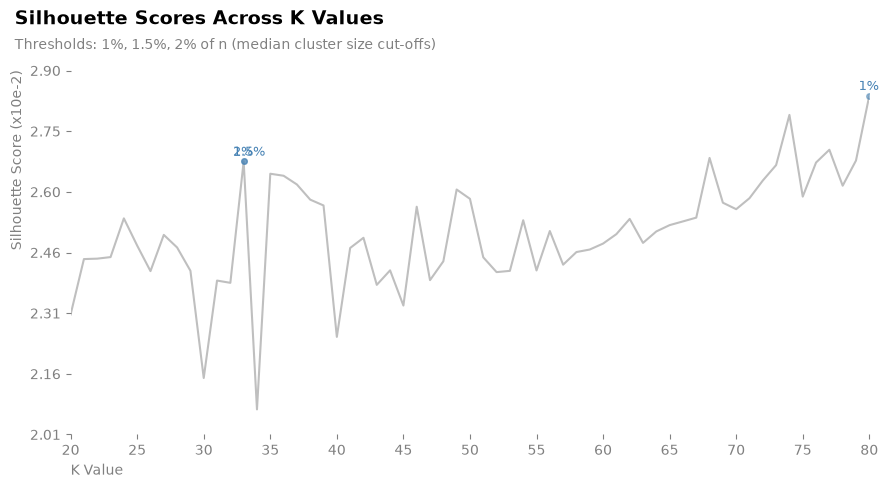

In [9]:
# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=metrics_df,
    x="K Value",
    y="Silhouette Score (x10e-2)",
    color="grey",
    alpha=0.5,
)

# Coordinates of the optimal K by threshold for annotation
for i, row in optimal_df.iterrows():
    ax.annotate(
        f"{row['Threshold Percent']}",
        xy=(row["Optimal K"], row["Silhouette Score (x10e-2)"]),
        xytext=(row["Optimal K"] - 0.8, row["Silhouette Score (x10e-2)"] + 0.014),
        fontsize=9,
        color="steelblue",
    )
    ax.plot(
        row["Optimal K"],
        row["Silhouette Score (x10e-2)"],
        "o",
        color="steelblue",
        markersize=4,
        alpha=0.5,
    )

# Clean borders by removing bottom/right spines
sns.despine(right=True, top=True, left=True, bottom=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("K Value", color="grey")
ax.set_ylabel("Silhouette Score (x10e-2)", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.tick_params(labelsize=10)

# Set axis alignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(metrics_df["K Value"].min(), metrics_df["K Value"].max())

# Use data-driven y limits and ticks for robustness
ymin = metrics_df["Silhouette Score (x10e-2)"].min()
ymax = metrics_df["Silhouette Score (x10e-2)"].max()
ypad = max((ymax - ymin) * 0.08, 0.02)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.xaxis.set_ticks(
    np.arange(metrics_df["K Value"].min(), metrics_df["K Value"].max() + 1, 5)
)
ax.yaxis.set_ticks(np.linspace(ymin - ypad, ymax + ypad, 7))

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))

# Title parameters
ax.set_title(
    label="Silhouette Scores Across K Values",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.07,
    y=1.07,
)

# Add subtitle in axes coordinates so it stays in place across scales
ax.text(
    x=-0.07,
    y=1.05,
    s="Thresholds: 1%, 1.5%, 2% of n (median cluster size cut-offs)",
    fontsize=10,
    color="grey",
    ha="left",
    va="bottom",
    transform=ax.transAxes,
)

plt.tight_layout()
plt.savefig(Config.KMEANS_PLOT_PATH, dpi=300, bbox_inches="tight")

print("\nSilhouette scores across K values:")
plt.show()

### Redundancy Ratio And Composite Scoring

This section penalises thematic overlap between clusters and combines it with silhouette quality.

Rule used:
- `Composite Score = Silhouette Score - Redundant Pair Ratio`

Value: this prevents selection of high-`K` solutions that improve separation marginally but duplicate themes heavily.

In [11]:
# ==========================================================
# Redundancy Ratio and Composite Scoring
# ==========================================================

# ----------------------------------------------------------
# 1. Compute redundant-cluster-pair ratio
# ----------------------------------------------------------
def compute_redundancy_ratio(cluster_labels_map: dict) -> float:
    """
    Calculate the proportion of cluster pairs whose top-term labels overlap
    by at least the configured redundancy threshold.

    The overlap denominator is the smaller of the two label sets so that
    clusters are considered redundant when most of the smaller cluster's
    descriptive terms are also present in the larger cluster.
    """
    label_sets = {
        cluster_id: set(cluster_label.split(", "))
        if isinstance(cluster_label, str)
        else set()
        for cluster_id, cluster_label in cluster_labels_map.items()
    }

    cluster_ids = list(label_sets.keys())

    # Generate every unique pair of clusters once.
    all_pairs = [
        (first_cluster_id, second_cluster_id)
        for index, first_cluster_id in enumerate(cluster_ids)
        for second_cluster_id in cluster_ids[index + 1 :]
    ]

    # A model with fewer than two clusters has no pairwise redundancy.
    if not all_pairs:
        return 0.0

    redundant_pair_count = 0

    for first_cluster_id, second_cluster_id in all_pairs:
        first_label_set = label_sets[first_cluster_id]
        second_label_set = label_sets[second_cluster_id]

        smaller_label_count = min(
            len(first_label_set),
            len(second_label_set),
        )

        # Ignore empty label sets because an overlap proportion cannot
        # meaningfully be calculated.
        if smaller_label_count == 0:
            continue

        overlap_ratio = (
            len(first_label_set & second_label_set)
            / smaller_label_count
        )

        if overlap_ratio >= Config.REDUNDANCY_OVERLAP_THRESHOLD:
            redundant_pair_count += 1

    return redundant_pair_count / len(all_pairs)


# ----------------------------------------------------------
# 2. Build human-readable cluster labels
# ----------------------------------------------------------
def build_labels_map(
    cluster_count: int,
    cluster_ids: np.ndarray,
    feature_names: np.ndarray,
    tfidf_matrix,
) -> dict:
    """
    Build a top-term label for every cluster using the mean TF-IDF weight
    of its members.

    np.argpartition() is used to retrieve the highest-weight terms without
    sorting the complete feature vector.
    """
    cluster_labels_map = {}
    top_term_count = Config.REDUNDANCY_LABEL_TOP_TERMS

    for cluster_id in range(cluster_count):
        member_indices = np.where(cluster_ids == cluster_id)[0]

        if len(member_indices) == 0:
            cluster_labels_map[cluster_id] = "Empty Cluster"
            continue

        mean_tfidf_vector = np.array(
            tfidf_matrix[member_indices].mean(axis=0)
        ).ravel()

        top_feature_indices = np.argpartition(
            mean_tfidf_vector,
            -top_term_count,
        )[-top_term_count:]

        # argpartition returns the correct features but not in ranked order,
        # so sort only the selected terms by descending TF-IDF weight.
        top_feature_indices = top_feature_indices[
            np.argsort(mean_tfidf_vector[top_feature_indices])[::-1]
        ]

        cluster_labels_map[cluster_id] = ", ".join(
            feature_names[top_feature_indices]
        )

    return cluster_labels_map


# ----------------------------------------------------------
# 3. Refit each finalist K with the stronger n_init setting
# ----------------------------------------------------------
print("Computing redundancy ratios for optimal K values...")

finalist_n_init = Config.KMEANS_FINALIST_N_INIT

# Cache models and labels because the same K may be selected under more than
# one screening threshold. This prevents unnecessary duplicate KMeans fits.
finalist_model_cache = {}
finalist_labels_cache = {}
redundancy_values = []

for _, optimal_row in optimal_df.iterrows():
    optimal_k_candidate = int(optimal_row["Optimal K"])

    if optimal_k_candidate not in finalist_model_cache:
        finalist_model = KMeans(
            n_clusters=optimal_k_candidate,
            random_state=Config.RANDOM_STATE,
            n_init=finalist_n_init,
        )

        finalist_model.fit(tfidf_normalised)

        finalist_model_cache[optimal_k_candidate] = finalist_model
        finalist_labels_cache[optimal_k_candidate] = finalist_model.labels_

    cluster_labels_map = build_labels_map(
        cluster_count=optimal_k_candidate,
        cluster_ids=finalist_labels_cache[optimal_k_candidate],
        feature_names=feature_names,
        tfidf_matrix=tfidf_sparse,
    )

    redundancy_ratio = compute_redundancy_ratio(cluster_labels_map)
    redundancy_values.append(redundancy_ratio)


# ----------------------------------------------------------
# 4. Calculate the heuristic composite score
# ----------------------------------------------------------
# Higher silhouette is desirable.
# Lower redundancy is desirable.
#
# Therefore:
#
#     Composite Score = Silhouette Score - Redundant Pair Ratio
#
# This is a project-specific heuristic rather than a standard clustering
# metric. It balances statistical cluster separation against thematic
# duplication between cluster labels.
optimal_df["Redundant Pair Ratio"] = redundancy_values

optimal_df["Composite Score"] = (
    optimal_df["Silhouette Score"]
    - optimal_df["Redundant Pair Ratio"]
)

optimal_df["n_init (Finalist)"] = finalist_n_init

optimal_df = optimal_df.sort_values(
    "Composite Score",
    ascending=False,
).reset_index(drop=True)


# ----------------------------------------------------------
# 5. Select the highest-scoring finalist K
# ----------------------------------------------------------
optimal_k = int(optimal_df.iloc[0]["Optimal K"])

print(f"Chosen optimal K: {optimal_k}")

display(optimal_df)

Computing redundancy ratios for optimal K values...
Chosen optimal K: 80


,Threshold Proportion,Threshold Percent,Threshold Abs,Optimal K,Silhouette Score,Silhouette Score (x10e-2),Davies-Bouldin Score,Median Cluster Size,Oversegmentation,Redundant Pair Ratio,Composite Score,n_init (Finalist)
0,0.010,1%,137.290,80.0,0.028403,2.840282,4.846098,176.5,False,0.026582,0.001821,10
1,0.015,1.5%,205.935,33.0,0.026794,2.679411,5.242804,433.0,False,0.037879,-0.011085,10
2,0.020,2%,274.580,33.0,0.026794,2.679411,5.242804,433.0,False,0.037879,-0.011085,10


### Cluster Labels

Final cluster labels are generated from top `TF-IDF` terms per cluster.

Value: this converts numerical clusters into interpretable operational themes.

In [12]:
# Importing the last dataset for final clustering and labelling
df = pd.read_parquet(Config.LEMMA_PARQUET_PATH, engine="auto")

# Final clustering using optimal_k
finalist_n_init = (
    int(optimal_df["n_init (Finalist)"].iloc[0])
    if "n_init (Finalist)" in optimal_df.columns
    else Config.KMEANS_FINALIST_N_INIT
)

if "finalist_model_cache" in globals() and optimal_k in finalist_model_cache:
    print(
        f"Reusing finalist-stage fitted model for k={optimal_k} "
        f"(n_init={finalist_n_init})..."
    )
    kmeans = finalist_model_cache[optimal_k]
    df["KMeans Cluster"] = kmeans.labels_
else:
    print(
        f"Performing final KMeans clustering with k={optimal_k} "
        f"(n_init={finalist_n_init}) (30-60s)..."
    )
    kmeans = KMeans(
        n_clusters=optimal_k, random_state=Config.RANDOM_STATE, n_init=finalist_n_init
    )
    df["KMeans Cluster"] = kmeans.fit_predict(tfidf_normalised)

# Generate top TF-IDF term labels for each cluster
labels_map, label_rows = {}, []
top_term_count = Config.REDUNDANCY_LABEL_TOP_TERMS

for cid in range(optimal_k):
    idx = np.where(df["KMeans Cluster"] == cid)[0]
    if len(idx) == 0:
        labels_map[cid] = "Empty Cluster"
        label_rows.append(
            {"Cluster ID": cid, "Keywords": "Empty Cluster", "Records": 0}
        )
        continue

    mean_vec = np.array(tfidf_normalised[idx].mean(axis=0)).ravel()
    top_idx = np.argpartition(mean_vec, -top_term_count)[-top_term_count:]
    top_idx = top_idx[np.argsort(mean_vec[top_idx])[::-1]]
    label_text = ", ".join(feature_names[top_idx])
    labels_map[cid] = label_text
    label_rows.append({"Cluster ID": cid, "Keywords": label_text, "Records": len(idx)})

cluster_labels_df = pd.DataFrame(label_rows).sort_values(by="Records", ascending=False)
df["Cluster Label"] = df["KMeans Cluster"].map(labels_map)

print("Generated cluster label summary:")
display(cluster_labels_df)
cluster_labels_df.to_csv(Config.CLUSTER_LABELS_PATH, index=False)

Reusing finalist-stage fitted model for k=80 (n_init=10)...
Generated cluster label summary:


,Cluster ID,Keywords,Records
26,26,"medical, secure, secure medical, medical datum...",466
1,1,"investment, analytic, tool, optimize, optimize...",428
42,42,"integration, integrate, project, project manag...",378
49,49,"security, medical, datum, protocol, medical da...",295
66,66,"crash, issue, software, application, software ...",291
...,...,...,...
17,17,"package, service, marketing, pricing, digital,...",50
10,10,"agency, marketing agency, marketing, campaign,...",48
71,71,"interface, user, user interface, project, dash...",46
35,35,"return, investment return, exchange, return ex...",44


### Actionability Scoring

Each cluster receives an `Actionability Score` built from:
- cohesion contribution
- high-similarity concentration

Value: this translates cluster structure into actionable prioritisation for service improvement.

In [18]:
# Compute cohesion & actionability using centroid-based cosine similarity
# Build per-ticket similarity to assigned KMeans centroid (TF-IDF space)
cluster_ids = df["KMeans Cluster"].to_numpy()
centroids = kmeans.cluster_centers_
centroid_norms = np.linalg.norm(centroids, axis=1)

centroid_similarity = np.zeros(len(cluster_ids), dtype=np.float32)
for cid in range(optimal_k):
    idx = np.where(cluster_ids == cid)[0]
    if len(idx) == 0:
        continue
    denom = centroid_norms[cid]
    if denom == 0:
        continue
    centroid_similarity[idx] = (
        np.asarray(tfidf_normalised[idx].dot(centroids[cid])).ravel() / denom
    )

# Prepare analysis dataframe aligned to clustering output
actionability_df = pd.DataFrame(
    {
        "KMeans Cluster": cluster_ids,
        "Mean Similarity": centroid_similarity,
    }
)
actionability_df["Cluster Label"] = actionability_df["KMeans Cluster"].map(labels_map)

# Cluster-level cohesion summary
cluster_summary_df = (
    actionability_df.groupby("KMeans Cluster", observed=False)
    .agg(
        Cluster_Size=("KMeans Cluster", "size"),
        Mean_Similarity=("Mean Similarity", "mean"),
    )
    .reset_index()
)
cluster_summary_df["Cluster Label"] = cluster_summary_df["KMeans Cluster"].map(
    labels_map
)
cluster_summary_df["Cohesion"] = (
    cluster_summary_df["Mean_Similarity"]
    * cluster_summary_df["Cluster_Size"]
    / len(actionability_df)
)

actionability_df = actionability_df.sort_values(["Mean Similarity", "KMeans Cluster"], ascending=False)
actionability_df.to_csv(Config.ACTIONABILITY_PATH, encoding="utf-8", index=True, index_label="Ticket Number")

print("\nActionability per ticket:")
display(actionability_df)

cluster_summary_df = cluster_summary_df.sort_values("Cohesion", ascending=False)
cluster_summary_df.to_csv(Config.CLUSTER_SUMMARY_PATH, encoding="utf-8", index=False)

print("\nCluster-level cohesion summary:")
display(cluster_summary_df)


Actionability per ticket:


,KMeans Cluster,Mean Similarity,Cluster Label
13550,54,0.856630,"screen, recorder, screen recorder, integration..."
8658,54,0.840295,"screen, recorder, screen recorder, integration..."
5493,54,0.835214,"screen, recorder, screen recorder, integration..."
6333,71,0.832393,"interface, user, user interface, project, dash..."
6521,71,0.829782,"interface, user, user interface, project, dash..."
...,...,...,...
10770,79,0.100503,"issue, software, problem, error, resolve, update"
6775,42,0.088211,"integration, integrate, project, project manag..."
9429,5,0.065738,"device, problem, issue, product, update, audio"
754,5,0.042871,"device, problem, issue, product, update, audio"



Cluster-level cohesion summary:


,KMeans Cluster,Cluster_Size,Mean_Similarity,Cluster Label,Cohesion
26,26,466,0.481692,"medical, secure, secure medical, medical datum...",0.016350
1,1,428,0.433626,"investment, analytic, tool, optimize, optimize...",0.013518
49,49,295,0.513469,"security, medical, datum, protocol, medical da...",0.011033
31,31,271,0.535583,"access attempt, unauthorized access, unauthori...",0.010572
13,13,290,0.497200,"security, medical, encryption, datum, hospital...",0.010502
...,...,...,...,...,...
71,71,46,0.628628,"interface, user, user interface, project, dash...",0.002106
24,24,60,0.465830,"alteryx, zoho, books, zoho books, zoho crm, crm",0.002036
35,35,44,0.575092,"return, investment return, exchange, return ex...",0.001843
10,10,48,0.456411,"agency, marketing agency, marketing, campaign,...",0.001596


### Top 10 Clusters

Clusters are ranked by normalised `Actionability Score` and the top ten are reported.

Value: this produces a concise intervention shortlist for operational planning and reporting.

In [21]:
# Create actionability ranking based on cohesion contribution and high-similarity concentration
overall_median_similarity = actionability_df["Mean Similarity"].median()

# Flag each ticket as High (above median similarity) or Low
actionability_df["Similarity Tier"] = np.where(
    actionability_df["Mean Similarity"] >= overall_median_similarity, "High", "Low"
)

actionability_df.to_csv(Config.ACTIONABILITY_PATH, encoding="utf-8", index=False)

# Compute per-cluster proportion of High-tier tickets
ratio_df = (
    actionability_df.groupby("KMeans Cluster", observed=False)["Similarity Tier"]
    .value_counts(normalize=True)
    .rename("Ratio")
    .reset_index()
)

high_ratio = ratio_df.loc[
    ratio_df["Similarity Tier"] == "High", ["KMeans Cluster", "Ratio"]
].rename(columns={"Ratio": "High Ratio"})

# Merge cohesion by cluster (safe alignment; keep all clusters)
actionability_dist = cluster_summary_df[
    ["KMeans Cluster", "Cohesion", "Cluster Label"]
].merge(high_ratio, on="KMeans Cluster", how="left")

# Fill clusters with no High tickets
actionability_dist["High Ratio"] = actionability_dist["High Ratio"].fillna(0.0)

# Map records from cluster_labels_df to actionability_dist (safe alignment)
records_map = cluster_labels_df.set_index("Cluster ID")["Records"].to_dict()
actionability_dist["Records"] = actionability_dist["KMeans Cluster"].map(records_map)

cohesion_max = actionability_dist["Cohesion"].max()
high_ratio_max = actionability_dist["High Ratio"].max()

if pd.isna(cohesion_max) or cohesion_max == 0:
    cohesion_max = 1.0
if pd.isna(high_ratio_max) or high_ratio_max == 0:
    high_ratio_max = 1.0

# Raw weighted score, then normalised to 0-1 for easier interpretation
raw_actionability = Config.CLUSTER_ACTIONABILITY_COHESION_WEIGHT * (
    actionability_dist["Cohesion"] / cohesion_max
) + Config.CLUSTER_ACTIONABILITY_HIGH_RATIO_WEIGHT * (
    actionability_dist["High Ratio"] / high_ratio_max
)
actionability_dist["Actionability Score"] = (
    raw_actionability / Config.CLUSTER_ACTIONABILITY_NORMALISER
)

# Sort by actionability score for reporting
actionability_dist = actionability_dist.sort_values("Actionability Score", ascending=False)

# Top 10 most actionable clusters
top10_actionable = (
    actionability_dist
    .head(10)
    .reset_index(drop=True)
)[
    [
        "KMeans Cluster",
        "Records",
        "Cluster Label",
        "Cohesion",
        "High Ratio",
        "Actionability Score",
    ]
]

print("\nTop 10 most actionable clusters:")
display(
    top10_actionable.style.format(
        {
            "Cohesion": "{:.4f}",
            "High Ratio": "{:.2%}",
            "Actionability Score": "{:.4f}",
        }
    )
)

actionability_dist.to_csv(Config.PRIORITY_PATH, encoding="utf-8", index=False)


Top 10 most actionable clusters:


,KMeans Cluster,Records,Cluster Label,Cohesion,High Ratio,Actionability Score
0,26,466,"medical, secure, secure medical, medical datum, datum, hospital",0.0163,66.31%,0.8737
1,31,271,"access attempt, unauthorized access, unauthorized, access, security, attempt",0.0106,85.61%,0.7252
2,49,295,"security, medical, datum, protocol, medical datum, security protocol",0.0110,80.34%,0.7230
3,1,428,"investment, analytic, tool, optimize, optimize investment, data",0.0135,42.06%,0.6745
4,60,271,"brand, growth, digital, brand growth, strategy, digital strategy",0.0102,74.91%,0.6691
5,13,290,"security, medical, encryption, datum, hospital, healthcare",0.0105,68.97%,0.6601
6,64,240,"breach, security breach, security, medical, hospital, datum",0.0088,76.25%,0.6231
7,62,179,"digital marketing, marketing, digital, brand, marketing strategy, strategy",0.0073,88.27%,0.6082
8,41,184,"brand, digital, marketing, strategy, social medium, medium",0.0074,85.87%,0.6034
9,69,180,"investment, analytic, service, analytic service, investment strategy, data analytic",0.0071,86.11%,0.5949


### Findings

Threshold screening produced one candidate per configured cut-off, and final selection used the composite objective:
- `Composite Score = Silhouette Score - Redundant Pair Ratio`

In this run, the selected model balanced separation quality with low thematic overlap and retained interpretability at practical cluster granularity.

Sensitivity diagnostics showed no material benefit from increasing initialisation budget for the representative shortlisted candidate, supporting the two-stage initialisation strategy.

Value delivered:
- reproducible `K` selection logic
- interpretable cluster themes
- prioritised shortlist using `Actionability Score`

This notebook completes the pipeline from representativeness validation and text normalisation to cluster-level operational prioritisation.